# 항공사 고객 만족도 예측 모델 구축 및 서비스 항목별 투자 우선순위 분석

## 문제 상황
항공사는 예산이 한정되어 있다. 기내식, 좌석, 와이파이, 온라인 체크인 등 승객이 불편을 느끼는 요소는 많지만, 이를 전부 동시에 개선할 수는 없다.

> **한정된 예산으로 승객의 불만족을 개선하려면, 여러 서비스 요소 중 어디를 먼저 건드려야 하는가?**

이 질문에 답하려면 단순히 "가장 불편해하는 항목이 무엇인가"만 봐서는 안 된다.

1. **많은 승객이 불편하다고 느끼지만, 개선해도 만족도 상승 효과가 크지 않은 항목**이 있을 수 있다. (다른 요인 때문에 불만족이 이미 고착되었거나, 항공사 통제 밖의 요인과 얽혀 있는 경우)
2. **가장 큰 불편 요소는 아니지만, 개선했을 때 만족도가 크게 뛰어오르는 항목**이 있을 수 있다. (소수만 겪는 문제지만 그 소수에게는 결정적인 항목)

이 프로젝트는 이 두 케이스를 구분해내고, "어디에 투자하면 실제로 만족도가 얼마나 오르는가"를 예측 모델 기반 시뮬레이션으로 알아내보고자 한다.


## 진행 순서
1. 데이터 분석
2. 승객 분포 파악 (PCA + K-means)
3. 만족도 예측 모델 구축 (Random Forest)
4. 무엇이 만족도를 좌우하는가
5. 투자 우선순위 — 불만율 × 개선효과
6. 예측 모델을 이용한 투자 전후 시뮬레이션
7. 결론


## 1. 데이터 분석

**Airline Passenger Satisfaction** (Kaggle) — https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

아메리칸 항공의 데이터를 기반으로 함

(US Airline passenger satisfaction survey)

- 승객 수: 25,976명
- 서비스 만족도 14개 항목 (0~5점 척도): 와이파이, 온라인 예약, 게이트 위치, 기내식, 온라인 탑승, 좌석 편의성, 기내 엔터테인먼트, 승무원 서비스, 다리 공간, 수하물 처리, 체크인, 기내 서비스, 청결도, 도착/출발 시간 편의성
- 승객 특성: 성별, 고객 등급(단골/비단골), 여행 목적(비즈니스/개인), 좌석 등급(비즈니스/이코노미), 나이, 비행 거리
- 운항 정보: 출발/도착 지연 시간(분)
- 타겟 변수: `satisfaction` — 최종 만족(satisfied) / 불만족(neutral or dissatisfied)

.

In [ ]:
#데이터 업로드
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')


import matplotlib as mpl
import subprocess

def setup_korean_font():
    candidates = [
        os.path.join(os.getcwd(), 'NotoSansKR.ttf'),
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    ]
    for path in candidates:
        if os.path.exists(path):
            try:
                fm.fontManager.addfont(path)
                name = fm.FontProperties(fname=path).get_name()
                return name
            except Exception:
                continue

    try:
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            return fm.FontProperties(fname=path).get_name()
    except Exception:
        pass
    return None

_font_name = setup_korean_font()
if _font_name:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_font_name] + plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('figs', exist_ok=True)


In [ ]:

import pandas as pd

df = pd.read_csv('/content/airline_satisfaction.csv')

display(df.head())
#데이터 확인

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [ ]:
print('결측치 확인:')
display(df.isnull().sum())

결측치 확인:


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


feature 중 승객 특성 항목(성별·나이·여행 목적·좌석 등급 등)은 항공사가 "투자"로 바꿀 수 없는 구조적 변수이므로, 본 분석은 항공사가 실제로 개선 가능한 14개 서비스 항목에 집중한다.

In [ ]:
#불필요한 feature분리
df = pd.read_csv('airline_satisfaction.csv').drop(columns=['Unnamed: 0', 'id'])
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Inflight service', 'Cleanliness']



##  사용할 Feature 목록(총 14개)

| Feature                         | 설명                               |
|:--------------------------------|:-----------------------------------|
| Inflight wifi service         | 기내 와이파이 서비스 만족도         |
| Departure/Arrival time convenient | 출발/도착 시간 편의성 만족도     |
| Ease of Online booking        | 온라인 예약 편의성 만족도          |
| Gate location                 | 게이트 위치 만족도                 |
| Food and drink                | 기내식 및 음료 만족도              |
| Online boarding               | 온라인 탑승 수속 만족도            |
| Seat comfort                  | 좌석 편의성 만족도                 |
| Inflight entertainment        | 기내 엔터테인먼트 만족도           |
| On-board service              | 기내 서비스 만족도                 |
| Leg room service              | 다리 공간 만족도                   |
| Baggage handling             | 수하물 처리 만족도                 |
| Checkin service               | 체크인 서비스 만족도               |
| Inflight service              | 비행 중 서비스 만족도              |
| Cleanliness                  | 청결도 만족도                      |

## 2. 승객 분포 파악 — PCA + K-means

14개 항목을 개별적으로 보기 전에, 승객들이 서비스에 대해 전반적으로 어떻게 갈려 있는지 먼저 확인한다.

In [ ]:
#pca(14 차원 데이터-> 2차원으로 압축)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[service_cols])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
print('2개 주성분 설명 분산 비율:', np.round(pca.explained_variance_ratio_, 3),
      '(합:', round(pca.explained_variance_ratio_.sum(), 3), ')')

loadings = pd.DataFrame(pca.components_.T, index=service_cols, columns=['PC1', 'PC2'])
print('\nPC1 상위 항목:')
print(loadings['PC1'].sort_values(key=abs, ascending=False).head(4).round(2))
print('\nPC2 상위 항목:')
print(loadings['PC2'].sort_values(key=abs, ascending=False).head(4).round(2))


2개 주성분 설명 분산 비율: [0.27  0.172] (합: 0.442 )

PC1 상위 항목:
Inflight entertainment    0.43
Cleanliness               0.36
Seat comfort              0.35
Food and drink            0.31
Name: PC1, dtype: float64

PC2 상위 항목:
Ease of Online booking               0.53
Inflight wifi service                0.45
Gate location                        0.43
Departure/Arrival time convenient    0.42
Name: PC2, dtype: float64


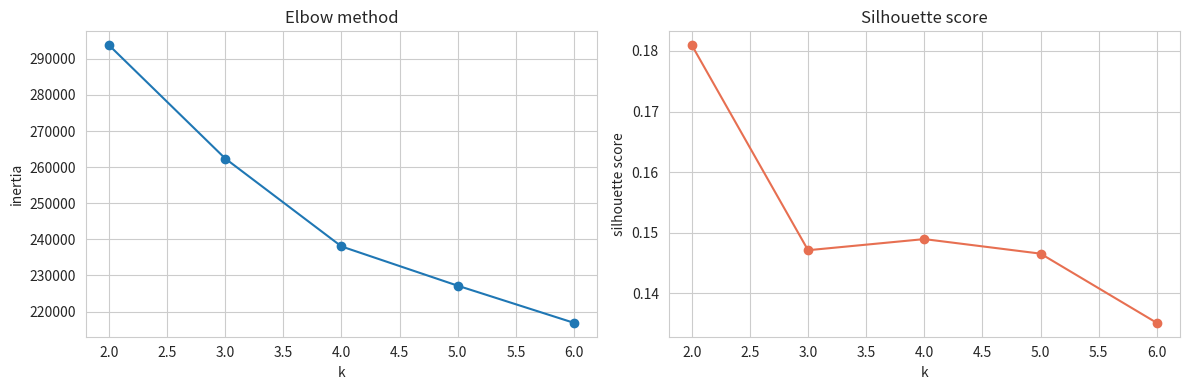

k별 silhouette score: {2: np.float64(0.181), 3: np.float64(0.147), 4: np.float64(0.149), 5: np.float64(0.147), 6: np.float64(0.135)}


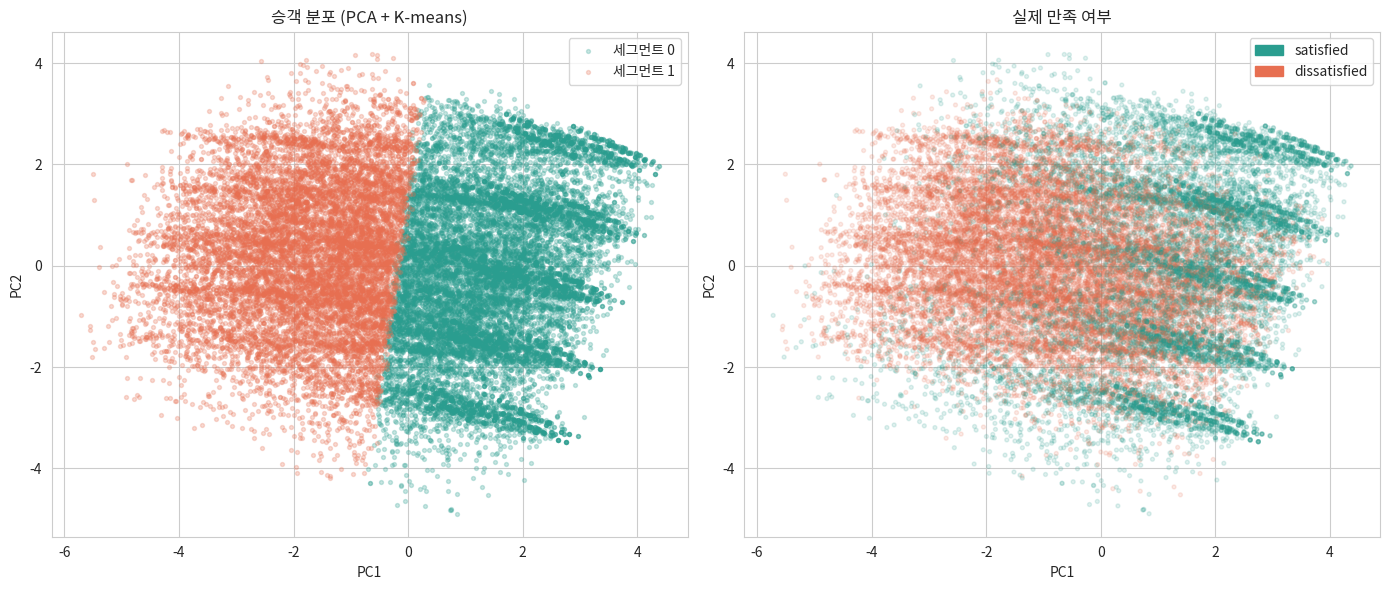

In [ ]:
#k 값 선택: elbow + silhouette
from sklearn.metrics import silhouette_score

inertias, sils = [], []
k_range = range(2, 7)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), 5000, replace=False)

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X_scaled[sample_idx], km_k.predict(X_scaled[sample_idx])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia'); axes[0].set_title('Elbow method')
axes[1].plot(list(k_range), sils, marker='o', color='#e76f51')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette score'); axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.savefig('figs/01b_k_selection.png', dpi=120)
plt.show()

print('k별 silhouette score:', dict(zip(k_range, np.round(sils, 3))))

#k-means (silhouette score 기준 k=2 선택)
km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
raw_segment = km.fit_predict(X_scaled)

# 세그먼트 라벨이 임의로 붙기 때문에, 만족 비율이 높은 쪽을 0번(초록)으로 재매핑
temp = pd.Series(raw_segment)
sat_rate_by_raw = pd.Series((df['satisfaction'] == 'satisfied').values).groupby(temp).mean()
remap = {sat_rate_by_raw.idxmax(): 0, sat_rate_by_raw.idxmin(): 1}
df['segment'] = temp.map(remap).values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2a9d8f', '#e76f51']
for seg in sorted(df['segment'].unique()):
    mask = df['segment'] == seg
    axes[0].scatter(pcs[mask, 0], pcs[mask, 1], s=8, alpha=0.25, color=colors[seg], label=f'세그먼트 {seg}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('승객 분포 (PCA + K-means)')
axes[0].legend()

sat_colors = df['satisfaction'].map({'satisfied': '#2a9d8f', 'neutral or dissatisfied': '#e76f51'})
axes[1].scatter(pcs[:, 0], pcs[:, 1], s=8, alpha=0.15, c=sat_colors)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('실제 만족 여부')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2a9d8f', label='satisfied'), Patch(color='#e76f51', label='dissatisfied')])
plt.tight_layout()
plt.savefig('figs/01_distribution.png', dpi=120)
plt.show()

 **분포 해석:**  승객들이 서비스에 대해 뚜렷하게 그룹핑 되진 않지만,오른쪽 그래프를 보면 만족/불만족이 PC1 축을 따라 상당히 갈리는 것을 알 수 있다. 다만 이 두 축만으로는 "어떤 항목을 개선해야 하는지"까지는 알 수 없으므로, 예측 모델을 통해 항목별 영향력을 확인한다


---


 silhouette score:

a = 그 점이 자기 군집 안의 다른 점들과 평균적으로 얼마나 가까운가
b = 그 점이 가장 가까운 다른 군집의 점들과 평균적으로 얼마나 가까운가

(b - a) / max(a, b)

자기 군집에는 가깝고(a 작음), 다른 군집과는 멀수록(b 큼) 1에 가까운 좋은 점수

군집 구분이 애매하면 0에 가까워지고, 아예 잘못 묶였으면 음수

이걸 모든 점에 대해 평균낸 게 실루엣 스코어(클수록 좋다)

In [ ]:
seg_summary = pd.DataFrame({
    '인원수': df.groupby('segment').size(),
    '비율(%)': (df.groupby('segment').size() / len(df) * 100).round(1),
    '만족비율(%)': (df.groupby('segment')['satisfaction'].apply(lambda x: (x == 'satisfied').mean()) * 100).round(1),
})
seg_summary


,인원수,비율(%),만족비율(%)
segment,,,
0,14357,55.3,64.8
1,11619,44.7,18.1


## 3. 만족도 예측 모델 구축 — Random Forest(base)


In [ ]:
#데이터 셋 분리
X = df[service_cols]
y = (df['satisfaction'] == 'satisfied').astype(int)
#training/test= 7.5:2.5
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
#랜덤포레스트 학습(개수 300개)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f'accuracy: {acc:.3f}')
print(classification_report(y_test, pred, target_names=['dissatisfied', 'satisfied']))


accuracy: 0.927
              precision    recall  f1-score   support

dissatisfied       0.94      0.93      0.93      3643
   satisfied       0.91      0.92      0.92      2851

    accuracy                           0.93      6494
   macro avg       0.93      0.93      0.93      6494
weighted avg       0.93      0.93      0.93      6494



학습을 진행하니 대략 91-92% 정확도로 만족 여부를 예측할 수 있음.

random forest 모델 말고 다른 모델을 넣을때도 이러한 결과가 나오는지 알아봐야함

## 3-1. 여러 머신러닝 모델 비교

Random Forest 하나의 성능만으로 모델의 적합성을 판단하지 않기 위해,
서로 다른 특성을 가진 Logistic Regression, Random Forest, XGBoost를 비교한다.

- Logistic Regression: 선형적인 관계를 가정하는 기본 분류 모델
- Random Forest: 여러 결정트리를 이용하는 앙상블 모델
- XGBoost: 이전 모델의 오차를 보완하면서 학습하는 부스팅 모델

또한 단 한 번의 train/test 분할 결과에 의존하지 않기 위해
5-Fold Cross Validation을 이용하여 모델의 성능을 비교한다.

### XGBoost

  
**Random Forest와의 차이**
- Random Forest: 여러 트리를 **동시에, 독립적으로** 만들고 평균 냄 (안정성 ↑)
- XGBoost: 트리를 **순서대로** 만들며 이전 트리의 오차를 계속 보완함 (정교함 ↑, 대신 학습 순서에 의존)

**AdaBoost와의 차이**

- AdaBoost: 틀린샘플의 가중치를 높이는 방식
- XGBoost: 잔차(오차)를 직접 예측해서 다음 트리를 보완

In [ ]:
# 모델 정의

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    )
}

# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = []

for name, model in models.items():

    result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        '모델': name,
        'Accuracy': result['test_accuracy'].mean(),
        'Precision': result['test_precision'].mean(),
        'Recall': result['test_recall'].mean(),
        'F1-score': result['test_f1'].mean(),
        'ROC-AUC': result['test_roc_auc'].mean()
    })

cv_df = pd.DataFrame(cv_results)

print('5-Fold Cross Validation 결과')
display(cv_df.round(4))

5-Fold Cross Validation 결과


,모델,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8114,0.7951,0.7686,0.7816,0.8745
1,Random Forest,0.9236,0.9173,0.9077,0.9125,0.9796
2,XGBoost,0.9358,0.9367,0.9158,0.9261,0.9861


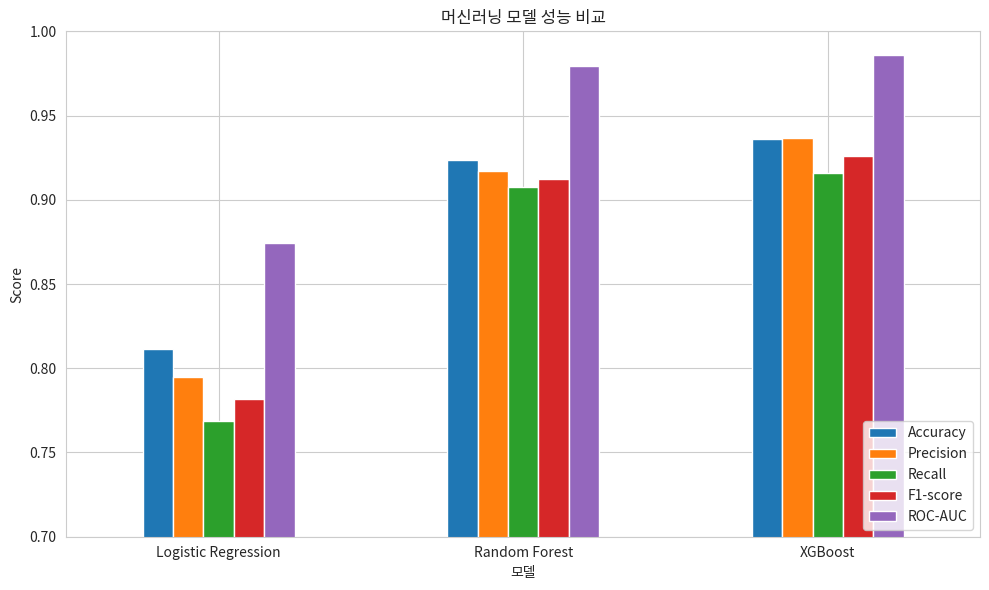

In [ ]:
# 모델별 성능 비교

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

cv_plot = cv_df.set_index('모델')[metrics]

ax = cv_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

ax.set_ylabel('Score')
ax.set_title('머신러닝 모델 성능 비교')
ax.set_ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# 최종 모델을 학습 데이터 전체로 학습
test_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        '모델': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

test_df = pd.DataFrame(test_results)

print('Test set 성능 비교')
display(test_df.round(4))

Test set 성능 비교


,모델,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8107,0.7924,0.7710,0.7815,0.8768
1,Random Forest,0.9265,0.9147,0.9183,0.9165,0.9811
2,XGBoost,0.9407,0.9375,0.9267,0.9321,0.9878


**결론:**  logistic regression보다 Random forest , XGBoost가 높은 성능을 보여 만족도와 서비스 평가 사이의 관계가 단순한 선형관계만으로는 설명되기 어렵다는 것을 확인했다.


(logistic regression은 출력값은 비선형이지만 입력변수랑 log odds가 선형)

## 4. 무엇이 만족도를 가장 크게 좌우하는가

총 14개의 feature들 중 어떤것이 가장 크게 만족도에 영향을 미치는 지 알아보자

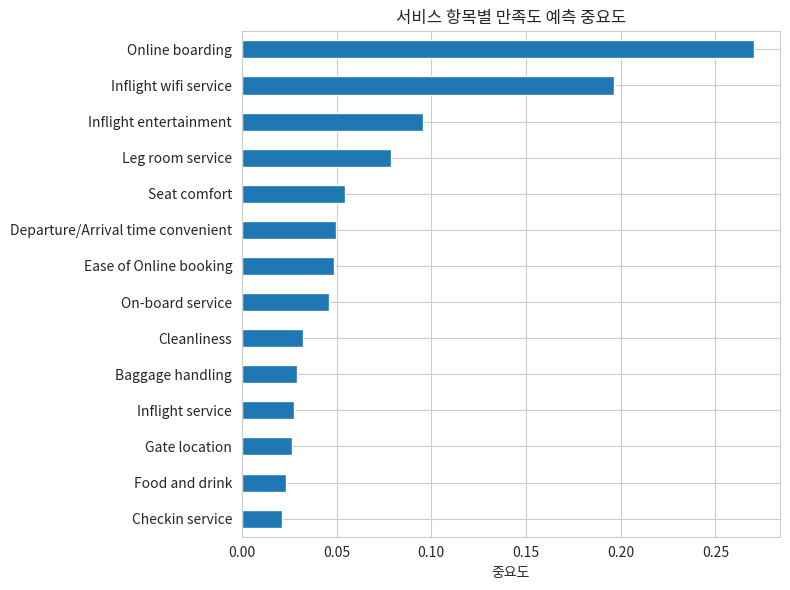

,0
Online boarding,0.270549
Inflight wifi service,0.196329
Inflight entertainment,0.095563
Leg room service,0.078650
Seat comfort,0.054673
Departure/Arrival time convenient,0.049815
Ease of Online booking,0.048811
On-board service,0.045935
Cleanliness,0.032387
Baggage handling,0.029017


In [ ]:
importance = pd.Series(rf.feature_importances_, index=service_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('중요도')
ax.set_title('서비스 항목별 만족도 예측 중요도')
plt.tight_layout()
plt.savefig('figs/02_importance.png', dpi=120)
plt.show()

importance


Online boarding(온라인 탑승 수속), Inflight wifi service(기내 와이파이), Leg room service(다리 공간)가 상위권이다.

하지만 이 중요도만으로 투자 우선순위를 정하면 안 된다. 중요도가 높아도 **이미 많은 승객이 만족하고 있는 항목**이라면 추가 투자의 실익이 작을 수 있고, 반대로 중요도가 상대적으로 낮아도 **개선했을 때 실제 전환 효과가 큰 항목**이라면 우선순위가 높아질 수 있다.

---



예를 들어

A항목- 불만족 승객 70% / feature importance : 높음

B항목- 불만족 승객 10%/ feature importance: 높음

이런 경우 중요도만 보고는 판단 할 수 없음



## 4-1. 모델별 Feature Importance 비교

Random Forest에서 확인한 중요 변수가 특정 모델에만 나타나는 결과인지 확인하기 위해,
XGBoost에서도 동일한 방식으로 Feature Importance를 계산한다.

두 모델에서 공통적으로 상위에 나타나는 서비스 항목은
모델의 종류와 관계없이 만족도 예측에 중요한 변수일 가능성이 높다고 판단한다.

In [ ]:
# XGBoost 모델 학습
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

xgb.fit(X_train, y_train)

# Feature Importance
rf_importance = pd.Series(
    rf.feature_importances_,
    index=service_cols
).sort_values(ascending=False)

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=service_cols
).sort_values(ascending=False)

importance_compare = pd.DataFrame({
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
})

display(importance_compare.round(4))

,Random Forest,XGBoost
Baggage handling,0.0290,0.0290
Checkin service,0.0210,0.0304
Cleanliness,0.0324,0.0384
Departure/Arrival time convenient,0.0498,0.0493
Ease of Online booking,0.0488,0.0309
Food and drink,0.0231,0.0272
Gate location,0.0265,0.0402
Inflight entertainment,0.0956,0.0852
Inflight service,0.0277,0.0255
Inflight wifi service,0.1963,0.1567


In [ ]:
importance_rank = pd.DataFrame({
    'Random Forest 순위':
        rf_importance.rank(ascending=False, method='min').astype(int),

    'XGBoost 순위':
        xgb_importance.rank(ascending=False, method='min').astype(int)
})

importance_rank['평균 순위'] = (
    importance_rank['Random Forest 순위'] +
    importance_rank['XGBoost 순위']
) / 2

importance_rank = importance_rank.sort_values('평균 순위')

display(importance_rank)

,Random Forest 순위,XGBoost 순위,평균 순위
Online boarding,1,1,1.0
Inflight wifi service,2,2,2.0
Inflight entertainment,3,3,3.0
Leg room service,4,4,4.0
Departure/Arrival time convenient,6,5,5.5
On-board service,8,6,7.0
Ease of Online booking,7,9,8.0
Seat comfort,5,11,8.0
Cleanliness,9,8,8.5
Gate location,12,7,9.5


1~4위 까지는 두 모델이 서로 같은 중요도를 가진다.

## 5. 투자 우선순위 — 불만율 × 개선효과

문제 상황에서 제기한 두 가지 축을 계산한다.

>1. **많은 승객이 불편하다고 느끼지만, 개선해도 만족도 상승 효과가 크지 않은 항목**

>불만율 높음/ 개선효과 낮음

>2. **가장 큰 불편 요소는 아니지만, 개선했을 때 만족도가 크게 뛰어오르는 항목**

>불만율 낮음/개선효과 높음

- **불만율**: 현재 해당 항목에 낮은 점수(0~2점)를 준 승객의 비율. "얼마나 많은 사람이 불편해하는가."
- **개선효과**: 예측 모델(random forest)을 이용해, 해당 항목의 점수를 낮은 수준(1점)에서 양호한 수준(4점)으로 올렸을 때 **예측 만족 확률이 평균적으로 얼마나 상승하는지**를 계산한 값 (Partial Dependence 방식). "실제로 개선했을 때 효과가 얼마나 큰가."


In [ ]:
unhappy_rate = (df[service_cols] <= 2).mean() * 100
# 평점이 2점보다 낮은 경우를 불만족이라고 기준
effects = {}
#아까 만든 모델을 이용해서 가상으로 해당 항목의 점수를 투자했다고 가정하고 1->4점으로 바꿔서 다시 만족도를 예측했을 때 나올 확률
for col in service_cols:
    X_low = X_test.copy(); X_low[col] = 1
    X_high = X_test.copy(); X_high[col] = 4#1->4점으로 바꿔서 계산
    p_low = rf.predict_proba(X_low)[:, 1].mean()
    p_high = rf.predict_proba(X_high)[:, 1].mean()
    effects[col] = (p_high - p_low) * 100

effect = pd.Series(effects)

matrix_df = pd.DataFrame({'불만율(%)': unhappy_rate, '개선효과(%p)': effect}).round(2)
matrix_df.sort_values('개선효과(%p)', ascending=False)


,불만율(%),개선효과(%p)
Online boarding,29.45,18.66
Inflight wifi service,45.39,18.23
Leg room service,29.58,11.28
Inflight entertainment,29.00,9.08
On-board service,25.36,6.03
Food and drink,33.24,3.82
Baggage handling,17.83,3.66
Inflight service,17.83,3.63
Seat comfort,25.66,3.52
Cleanliness,28.46,3.10


 `Gate location`(게이트 위치), `Departure/Arrival time convenient`(출발/도착 시간 편의성)는 개선효과가 음수로 나온다.

  이는 점수를 올려도(1->4점으로 변경한 것) 모델이 예측하는 만족 확률이 거의 오르지 않는다는 뜻으로, 항공사가 점수 자체를 올린다고 해서 만족도가 따라 오르지 않는 항목일 수 있다고 본다. (다른 요인과 얽혀 있거나, 애초에 만족도와 약한 관계).

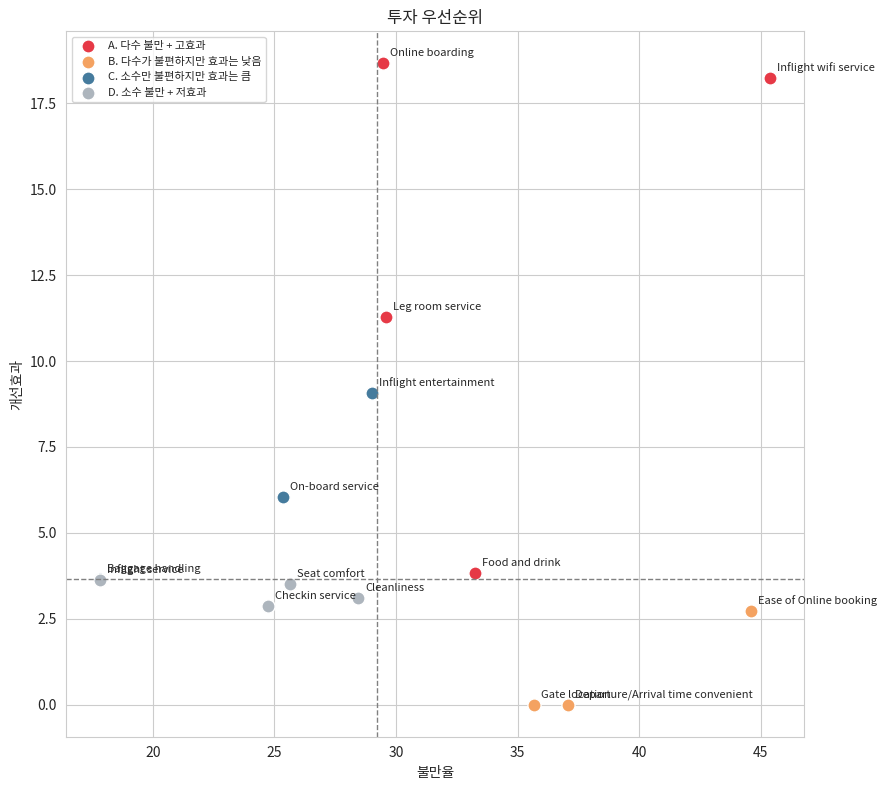

,불만율(%),개선효과(%p),구분
Online boarding,29.45,18.66,A. 다수 불만 + 고효과
Inflight wifi service,45.39,18.23,A. 다수 불만 + 고효과
Leg room service,29.58,11.28,A. 다수 불만 + 고효과
Food and drink,33.24,3.82,A. 다수 불만 + 고효과
Ease of Online booking,44.60,2.73,B. 다수가 불편하지만 효과는 낮음
Departure/Arrival time convenient,37.09,-7.63,B. 다수가 불편하지만 효과는 낮음
Gate location,35.67,-3.04,B. 다수가 불편하지만 효과는 낮음
Inflight entertainment,29.00,9.08,C. 소수만 불편하지만 효과는 큼
On-board service,25.36,6.03,C. 소수만 불편하지만 효과는 큼
Baggage handling,17.83,3.66,C. 소수만 불편하지만 효과는 큼


In [ ]:
import matplotlib.pyplot as plt

matrix_df['개선효과_clip'] = matrix_df['개선효과(%p)'].clip(lower=0)
med_u = matrix_df['불만율(%)'].median()
med_e = matrix_df['개선효과_clip'].median()

def quadrant(row):
    high_u = row['불만율(%)'] >= med_u
    high_e = row['개선효과_clip'] >= med_e
    if high_u and high_e:
        return 'A. 다수 불만 + 고효과'
    elif high_u and not high_e:
        return 'B. 다수가 불편하지만 효과는 낮음'
    elif not high_u and high_e:
        return 'C. 소수만 불편하지만 효과는 큼'
    else:
        return 'D. 소수 불만 + 저효과'

matrix_df['구분'] = matrix_df.apply(quadrant, axis=1)

fig, ax = plt.subplots(figsize=(9, 8))

quad_colors = {
    'A. 다수 불만 + 고효과': '#e63946',
    'B. 다수가 불편하지만 효과는 낮음': '#f4a261',
    'C. 소수만 불편하지만 효과는 큼': '#457b9d',
    'D. 소수 불만 + 저효과': '#adb5bd',
}

for q, sub in matrix_df.groupby('구분'):
    ax.scatter(sub['불만율(%)'], sub['개선효과_clip'], s=90, color=quad_colors[q], label=q, edgecolor='white')
    for name, row in sub.iterrows():
        ax.annotate(name, (row['불만율(%)'], row['개선효과_clip']), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axvline(med_u, color='gray', linestyle='--', linewidth=1)
ax.axhline(med_e, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('불만율')
ax.set_ylabel('개선효과')
ax.set_title('투자 우선순위')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('figs/03_priority_matrix.png', dpi=120)
plt.show()

matrix_df.sort_values(['구분', '개선효과_clip'], ascending=[True, False])[['불만율(%)', '개선효과(%p)', '구분']]

- **group A**. — **온라인 탑승수속 ,기내 와이파이, 다리 공간, 식음료**: 많은 승객이 불편해하고, 개선 시 효과도 크다.
- **group B.** — **온라인 예매 편의성, 출발/도차 시간 편의성, 게이트 위치**: 불만율은 높지만, 점수를 올려도 만족도 개선으로 잘 이어지지 않는다. 예산을 투입해도 체감 효과가 작을 가능성이 크다
- **group C.** — **기내 엔터테인먼트, 기내 서비스 만족도, 비행 중 서비스 만족도**: 불편을 느끼는 승객 비율 자체는 중간 이하지만, 개선했을 때 만족도 상승 폭이 크다.
- **group D.** — **좌석 편의성, 수하물 처리, 청결도, 체크인 서비스**: 불만율도 낮고 효과도 낮아 우선순위가 낮다.


## 6. 예측 모델을 이용한 투자 전후 시뮬레이션

 A그룹(`Online boarding`, `Inflight wifi service`, `Leg room service`, `Food and drink`) 에 투자해 점수를 끌어올렸다고 가정하고, 예측 모델로 투자 전후의 전체 만족률이 얼마나 달라지는지 시뮬레이션한다.

비교를 위해 D그룹(`Seat comfort`, `Baggage handling`, `Cleanliness`, `Checkin service`) 4개 항목 전체를 개선했을 때도 같은 방식으로 계산한다.

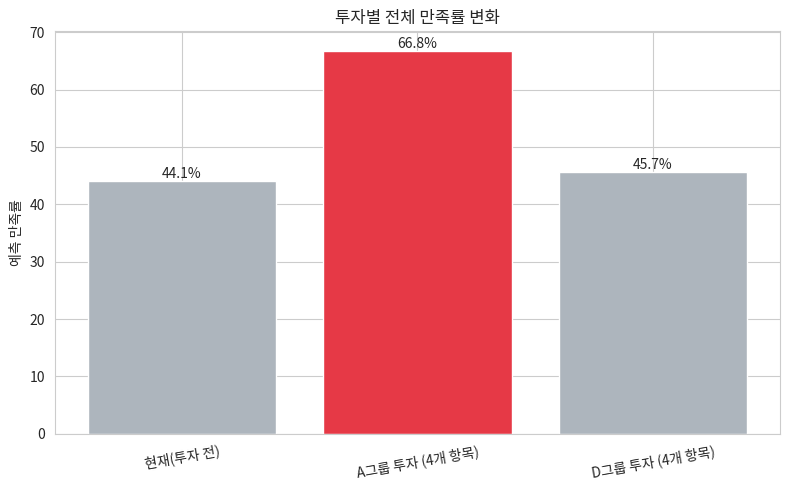

,시나리오,예측 만족률(%),상승폭(%p)
0,현재(투자 전),44.07,0.00
1,A그룹 투자 (4개 항목),66.80,22.73
2,D그룹 투자 (4개 항목),45.67,1.60


In [ ]:
baseline_rate = rf.predict(X_test).mean()

# A그룹 전체
group_A = ['Online boarding', 'Inflight wifi service', 'Leg room service', 'Food and drink']
#  D그룹 전체 (비교용)
group_D = ['Seat comfort', 'Baggage handling', 'Cleanliness', 'Checkin service']

# 가정 1: A그룹 4개 항목이 4점 미만인 승객을 4점으로 개선
X_sim_A = X_test.copy()
for col in group_A:
    X_sim_A[col] = X_sim_A[col].clip(lower=4)
rate_A = rf.predict(X_sim_A).mean()

# 가정 2: D그룹 4개 항목을 4점으로 개선 (비교용)
X_sim_D = X_test.copy()
for col in group_D:
    X_sim_D[col] = X_sim_D[col].clip(lower=4)
rate_D = rf.predict(X_sim_D).mean()

sim_result = pd.DataFrame({
    '시나리오': ['현재(투자 전)', 'A그룹 투자 (4개 항목)', 'D그룹 투자 (4개 항목)'],
    '예측 만족률(%)': [baseline_rate*100, rate_A*100, rate_D*100],
})
sim_result['상승폭(%p)'] = sim_result['예측 만족률(%)'] - baseline_rate*100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sim_result['시나리오'], sim_result['예측 만족률(%)'], color=['#adb5bd', '#e63946', '#adb5bd'])
ax.set_ylabel('예측 만족률')
ax.set_title('투자별 전체 만족률 변화')
for bar, val in zip(bars, sim_result['예측 만족률(%)']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('figs/04_simulation.png', dpi=120)
plt.show()

sim_result.round(2)

**가상 시뮬레이션 결과**: A그룹(4개 항목)을 개선하면 전체 예측 만족률이 약 **22.7%p** 상승하는 반면, D그룹(4개 항목)을 개선하면 상승폭은 **1.6%p**에 그친다. 두 그룹 모두 같은 개수(4개)의 항목을 동일한 방식(4점 미만 → 4점)으로 개선했는데도 이렇게 차이가 나는 것은, 우선순위가  실제 예측 모델 상에서 유의미하다는 것을 보여준다.

## 7. 결론

**Q. 한정된 예산으로 승객의 불만족을 개선하려면, 어디를 먼저 건드려야 하는가?**

단순히 "불만율이 가장 높은 항목"이나 "feature importance(중요도)가 가장 높은 항목"으로는 이 질문에 답할 수 없다. 두 지표 모두 "개선했을 때 실제로 만족도가 오르는가"는 말해주지 않기 때문이다. 그래서 불만율 × 개선효과로 다시 줄을 세워, top 5를 뽑았다.

| 순위 | 항목 | 불만율(%) | 개선효과(%p) |
|---|---|---|---|
| 1 | Inflight wifi service | 45.4 | 18.2 |
| 2 | Online boarding | 29.5 | 18.7 |
| 3 | Leg room service | 29.6 | 11.3 |
| 4 | Inflight entertainment | 29.0 | 9.1 |
| 5 | On-board service | 25.4 | 6.0 |

 (`Ease of Online booking`, `Departure/Arrival time convenient`, `Gate location`은 불만율은 높은데도  순위에 들지 못했다 —> 점수를 올려도 만족도 상승으로 잘 이어지지 않기 때문이다.)

**A. A그룹(Online boarding, Inflight wifi service, Leg room service, Food and drink).**

 A그룹을 개선하는 시뮬레이션을 돌린 결과 전체 예측 만족률이 **22.7%p** 상승했다. 반면 불만율은 낮지만 비교군으로 개선해본 D그룹(Seat comfort, Baggage handling, Cleanliness, Checkin service) 은 **1.6%p** 상승에 그쳤다. 우선순위가 실제 모델 상에서 유의미하다는 것을 보여준다.

**항공사 입장에서의 결론**: 한정된 예산은 Inflight wifi service와 Online boarding에 가장 먼저 투입하고, Leg room service·Food and drink를 함께 검토하는 것이 맞다. 반대로 Ease of Online booking이나 Departure/Arrival time convenient처럼 불만은 많지만 개선 효과가 낮은 항목은, 겉보기 불만율만 보고 예산을 배정하면 안 된다.

### 한계와 개선 방향

**비즈니스 해석 측면**
- `개선효과`는 Partial Dependence 방식으로 추정한 값으로, 관심 항목의 점수만 바꾸고 나머지는 그대로 둔 채 계산한 것이라 실제 투자의 인과적 효과와 다를 수 있다.
- 14개 서비스 항목은 같은 승객이 매긴 주관적 평가라 서로 상관관계가 높고 전반적 승객의 성향이 여러 항목에 동시에 반영되었을 가능성이 있다.(데이터가 주관적일 수 있음)

**모델링 방법론 측면**

- Partial Dependence에서 "1점→4점"이라는 기준값이 임의적이다. 기준을 바꿔도 top 5 순위가 안정적인지 민감도 분석이 필요하다.

여름동안 다들 너무 수고하셨습니다 ㅎㅁㅎ
